# Librerías

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.integrate import dblquad, quad
from scipy.integrate import solve_ivp, simpson


In [2]:
mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

# Funciones

Para un modelo de preheating con $V(\phi) = \lambda \phi^4$ tenemos que las ecuaciones dinámicas adimensionales para el background son:

$$\begin{cases}
    \displaystyle \frac{d^2 \tilde{\phi}}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\phi}}{d \tilde{t}} + \tilde{\phi}^3 &= 0  \\ \\
    \displaystyle \frac{d^2 a}{d \tilde{t}^2} + \frac{a}{3} \left[ \left( \frac{d \tilde{\phi}}{d \tilde{t}} \right)^2 - \frac{\tilde{\phi}^4}{4} \right] &= 0
\end{cases} \tag{1}$$

Y para las perturbaciones, las ecuaciones adimensionales son:

$$\begin{cases}
    \displaystyle \frac{d^2 \delta \tilde{\phi}_k}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\phi}_k}{d \tilde{t}} + \left( \frac{\tilde{k}^2}{a^2} + 3 \tilde{\phi}^2 \right) \delta \tilde{\phi}_k &= 0\\
    \displaystyle \frac{d^2 \tilde{\chi}_k}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\chi}_k}{d \tilde{t}} + \left( \frac{\tilde{k}^2}{a^2} + g^2 \tilde{\phi}^2 \right) \tilde{\chi}_k &= 0
\end{cases} \tag{2}$$

In [3]:
"""Floquet"""

# Matriz de monodromía y calculo de los coeficientes de Floquet
def mu_lphi4(k, q, y0, Tosc):
    phi0, phi_dot0 = y0

    def pert(t, y, k, q):
        phi, phi_dot, chi_k, chi_dot_k = y
        phi_ddot = - phi**3
        chi_ddot_k = - (k**2 + q * phi**2) * chi_k
        return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

    t_span = (0, Tosc)

    sol1 = solve_ivp(pert, t_span, [phi0, phi_dot0, 1.0, 0.0], t_eval=[Tosc], method='RK45', rtol=1e-6, args=(k, q))
    y_final1 = sol1.y[:, -1]

    sol2 = solve_ivp(pert, t_span, [phi0, phi_dot0, 0.0, 1.0], t_eval=[Tosc], method='RK45', rtol=1e-6, args=(k, q))
    y_final2 = sol2.y[:, -1]

    M = np.array([
        [y_final1[2], y_final2[2]],
        [y_final1[3], y_final2[3]]
    ])

    tr_M = np.trace(M)
    argument = np.abs(tr_M / 2.0)

    if argument > 1.0:
        mu = np.arccosh(argument) / Tosc
        return mu
    else:
        return 0.0

# Calculo del periodo de oscilación del inflatón en el potencial lphi4
def oscilation(E):
    def integrand(phi):
        V = 0.25 * phi**4
        return 1.0 / np.sqrt(2 * (E - V))
    phimax = (4*E)**(1/4)
    integral, _ = quad(integrand, 0, phimax)
    Tosc = 4*integral
    return Tosc

# Guardar los datos en un archivo CSV
def save_csv(qs, Aks, mu, filename='results'):
    output = np.zeros((len(Aks)+1, len(qs)+1))
    output[0, 1:] = qs
    output[1:, 0] = Aks
    output[1:, 1:] = np.real(mu)
    np.savetxt(f"{filename}.csv", output, delimiter=",")

In [4]:
"""Dinámica"""

# Dinamica sin expansión del universo para el modelo lphi4
def pert(t, y, k, q):
    phi, phi_dot, chi_k, chi_dot_k = y
    phi_ddot = - phi**3
    chi_ddot_k = - (k**2 + q * phi**2) * chi_k
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

# Dinamica con expansión del universo para el modelo lphi4
def pert_exp(t, y, k, q):
    phi, phi_dot, chi_k, chi_dot_k, a, a_dot = y

    # Evolución de a(t)
    a_ddot = - a/3 * (phi_dot**2 - phi**4/4)
    H = a_dot/a
    
    # Ecuación para φ
    phi_ddot = -3 * H * phi_dot - phi **3
    
    # Ecuaciones para χ_k
    chi_ddot_k = - 3 * H * chi_dot_k - (k ** 2 / a**2 + q * phi**2) * chi_k 
    
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k, a_dot, a_ddot]

# Número de partículas producidas en el modo k
def number(k, q, phi, chik, chidot, a):
    omega_k = np.sqrt(k**2/a**2 + q * phi**2)
    nk = omega_k / 2 * ( (np.abs(chidot)/omega_k)**2 + np.abs(chik)**2 )
    return nk

#-------------------------------------------------------------------------------------------------------------------------------------
"""Condiciones iniciales"""
def CI(k, q):
    # Background
    phi0 = 1
    phi_dot0 = phi0**2/np.sqrt(2)

    # Perturbaciones
    Omega_chi = np.sqrt(k**2 + q * phi0**2)
    chi_k0 = 0 #1/(np.sqrt(2 * Omega_chi))
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi))) #np.sqrt(Omega_chi/2)

    y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]
    return y0

def CI_exp(k, q):
    # Background
    phi0 = 1
    phi_dot0 = phi0**2/np.sqrt(2)
    areh = 1
    a_dot0 = np.sqrt( (phi_dot0**2/2 + phi0**4/4) / 3 ) * areh

    # Perturbaciones
    Omega_chi = np.sqrt(k**2 + q * phi0**2)
    chi_k0 = 0 #1/(np.sqrt(2 * Omega_chi))
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi))) #np.sqrt(Omega_chi/2)

    y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0, areh, a_dot0]
    return y0

In [5]:
"""Espectro de potencias"""

# Armamos una función para calcular chi_k para un array de ks a todo tiempo
def chi_modes(q, ks, t_span, n_t=500, seed=None):
    t_eval = np.linspace(t_span[0], t_span[1], n_t)

    # Obtenemos el background phi(t)
    phi0 = 1.0
    phi_dot0 = phi0**2 / np.sqrt(2)

    def background(t, y):
        phi, phi_dot = y
        return [phi_dot, -phi**3]

    sol_bg = solve_ivp(background, t_span, [phi0, phi_dot0], t_eval=t_eval, method='RK45', rtol=1e-6)
    phi_t = sol_bg.y[0]

    phi_interp = interp1d(sol_bg.t, phi_t, kind='cubic', bounds_error=False, fill_value='extrapolate') # Interpolamos para poder calcular chi en cualquier tiempo

    # Calculamos chis
    ks = np.array(ks)
    n_k = len(ks)
    Omega0 = np.sqrt(ks**2 + q * phi0**2)

    chi0 = np.zeros(n_k)
    rng = np.random.default_rng(seed)
    chidot0 = rng.normal(loc=0.0, scale=1.0/np.sqrt(2.0 * Omega0))

    y0 = np.concatenate([chi0, chidot0])  # [chi_0..chi_nk-1, chidot_0..chidot_nk-1]

    def chi_system(t, y):
        chi = y[:n_k]
        chidot = y[n_k:]
        phi = phi_interp(t)
        chiddot = - (ks**2 + q * phi**2) * chi
        return np.concatenate([chidot, chiddot])

    sol = solve_ivp(chi_system, t_span, y0, t_eval=t_eval, method='RK45', rtol=1e-6) # Resolvemos la ecuación para todos los ks a la vez

    chi_vals = sol.y[:n_k, :] # Junto todos los valores de chi_k(t) en una matriz 

    return t_eval, np.array(chi_vals)


def chi_modes_exp(q, ks, t_span, n_t=500, seed=None):
    t_eval = np.linspace(t_span[0], t_span[1], n_t)

    # Obtenemos el background
    phi0 = 1.0
    phi_dot0 = phi0**2 / np.sqrt(2)
    areh = 1.0
    a_dotreh = np.sqrt((phi_dot0**2/2 + phi0**4/4) / 3) * areh

    def background_exp(t, y):
        phi, phi_dot, a, a_dot = y
        H = a_dot / a
        phi_ddot = -3.0 * H * phi_dot - phi**3
        a_ddot = - a/3.0 * (phi_dot**2 - phi**4 / 4.0)
        return [phi_dot, phi_ddot, a_dot, a_ddot]

    sol_bg = solve_ivp(background_exp, t_span, [phi0, phi_dot0, areh, a_dotreh], t_eval=t_eval, method='RK45', rtol=1e-6)

    phi_t = sol_bg.y[0]
    a_t = sol_bg.y[2]
    a_dot_t = sol_bg.y[3]

    # Interpoladores
    phi_interp = interp1d(sol_bg.t, phi_t, kind='cubic', bounds_error=False, fill_value='extrapolate')
    a_interp = interp1d(sol_bg.t, a_t, kind='cubic', bounds_error=False, fill_value='extrapolate')
    a_dot_interp = interp1d(sol_bg.t, a_dot_t, kind='cubic', bounds_error=False, fill_value='extrapolate')

    # Calculamos chi_k
    ks = np.array(ks)
    n_k = len(ks)

    Omega0 = np.sqrt(ks**2 / areh**2 + q * phi0**2)
    chi0 = np.zeros(n_k)
    rng = np.random.default_rng(seed)
    chidot0 = rng.normal(loc=0.0, scale=1.0/np.sqrt(2.0 * Omega0))
    y0 = np.concatenate([chi0, chidot0])

    def chi_system_exp(t, y):
        chi = y[:n_k]
        chidot = y[n_k:]
        phi = phi_interp(t)
        a = a_interp(t)
        a_dot = a_dot_interp(t)
        H = a_dot / a
        chiddot = -3.0 * H * chidot - (ks**2 / (a**2) + q * phi**2) * chi
        return np.concatenate([chidot, chiddot])

    sol = solve_ivp(chi_system_exp, t_span, y0, t_eval=t_eval, method='RK45', rtol=1e-6)
    chi_vals = sol.y[:n_k, :]

    return t_eval, np.array(chi_vals), a_interp(t_eval)


In [6]:
"""Espectro de ondas gravitacionales"""

def rhoGW(k, t_chi, chi_interp, p0, pf, n_p=80, n_x=80):
    # Definimos una grilla en p y x para la integración
    p_grid = np.linspace(p0, pf, n_p)
    x_grid = np.linspace(-1.0, 1.0, n_x)
    P, X = np.meshgrid(p_grid, x_grid, indexing='ij')

    # kp = |k - p| = k² + p² - 2 k p x
    KP = np.sqrt(k**2 + P**2 - 2.0 * k * P * X)

    # obtener chi_p para todos los kp a la vez y los interpolo
    kp_vals = KP.ravel()
    chi_p_all = chi_interp(kp_vals)           
    n_t = chi_p_all.shape[1]
    chi_p = chi_p_all.reshape((n_p, n_x, n_t))  
    chi_k = chi_interp(k)
                          
    # Calculo de antemano sin(k t) y cos(k t) para reducir tiempos en la integración de Is e Ic
    sin_k_t = np.sin(k * t_chi)                
    cos_k_t = np.cos(k * t_chi)

    # Calculo Is y Ic para todos los p,x a la vez
    integrand_s = sin_k_t[None, None, :] * chi_k[None, None, :] * chi_p
    integrand_c = cos_k_t[None, None, :] * chi_k[None, None, :] * chi_p
    Is_array = simpson(integrand_s, x=t_chi, axis=-1)
    Ic_array = simpson(integrand_c, x=t_chi, axis=-1)

    # Integro en x y p
    factor = (P**6) * (1 - X**2)**2
    integrand_px = factor * (np.abs(Is_array)**2 + np.abs(Ic_array)**2)
    int_over_x = np.trapz(integrand_px, x_grid, axis=1)
    rho_val = np.trapz(int_over_x, p_grid)               

    return rho_val

# Dinámica de los campos

## Análisis Floquet

### Cálculo Floquets

In [7]:
# Verifico si el archivo de inestabilidades existe, sino lo armo
nombre = "Floquet"

if not os.path.exists(nombre + ".csv"):
    phi0 = 1
    phi_dot0 = phi0**2/np.sqrt(2)

    y0 = (phi0, phi_dot0)
    E = 0.5 * phi_dot0**2 + 0.25 * phi0**4

    qs = np.linspace(0, 25, 300)
    ks = np.logspace(-2, 2, 300)

    # Q, K = np.meshgrid(qs, ks)
    mu = np.zeros((len(ks), len(qs)), dtype=complex)
    Tosc = oscilation(E)

    for i, q in enumerate(tqdm(qs)):
        for j, k in enumerate(ks):
            mu[j, i] = mu_lphi4(k, q, y0, Tosc)

    # Guardemos los resultados en un archivo CSV
    save_csv(qs, ks, mu, filename = nombre)
    
else:
    data = np.loadtxt(nombre + ".csv", delimiter=",")
    qs = data[0, 1:]
    ks = data[1:, 0]
    mu = data[1:, 1:]

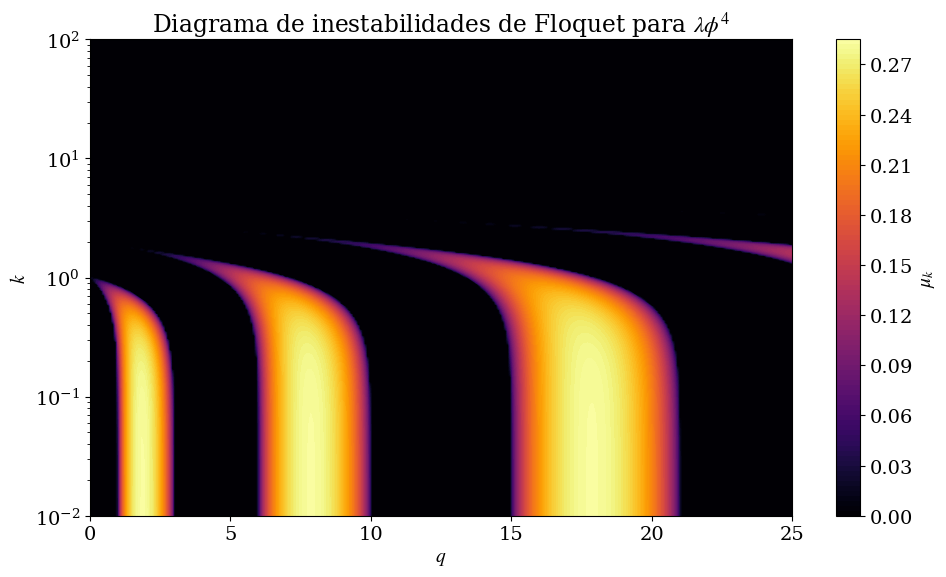

In [8]:
# Ahora grafiquemos el diagrama de inestabilidades
plt.figure(figsize=(10, 6))
plt.contourf(qs, ks, np.real(mu), levels=100, cmap='inferno')
plt.colorbar(label=r'$\mu_k$')
plt.xlabel(r'$q$')
plt.ylabel(r'$k$')
plt.yscale('log')
plt.title(r'Diagrama de inestabilidades de Floquet para $\lambda \phi^4$')
plt.tight_layout()
plt.savefig("Floquet_lphi4.pdf", format = "pdf")

### $\mu(k)$

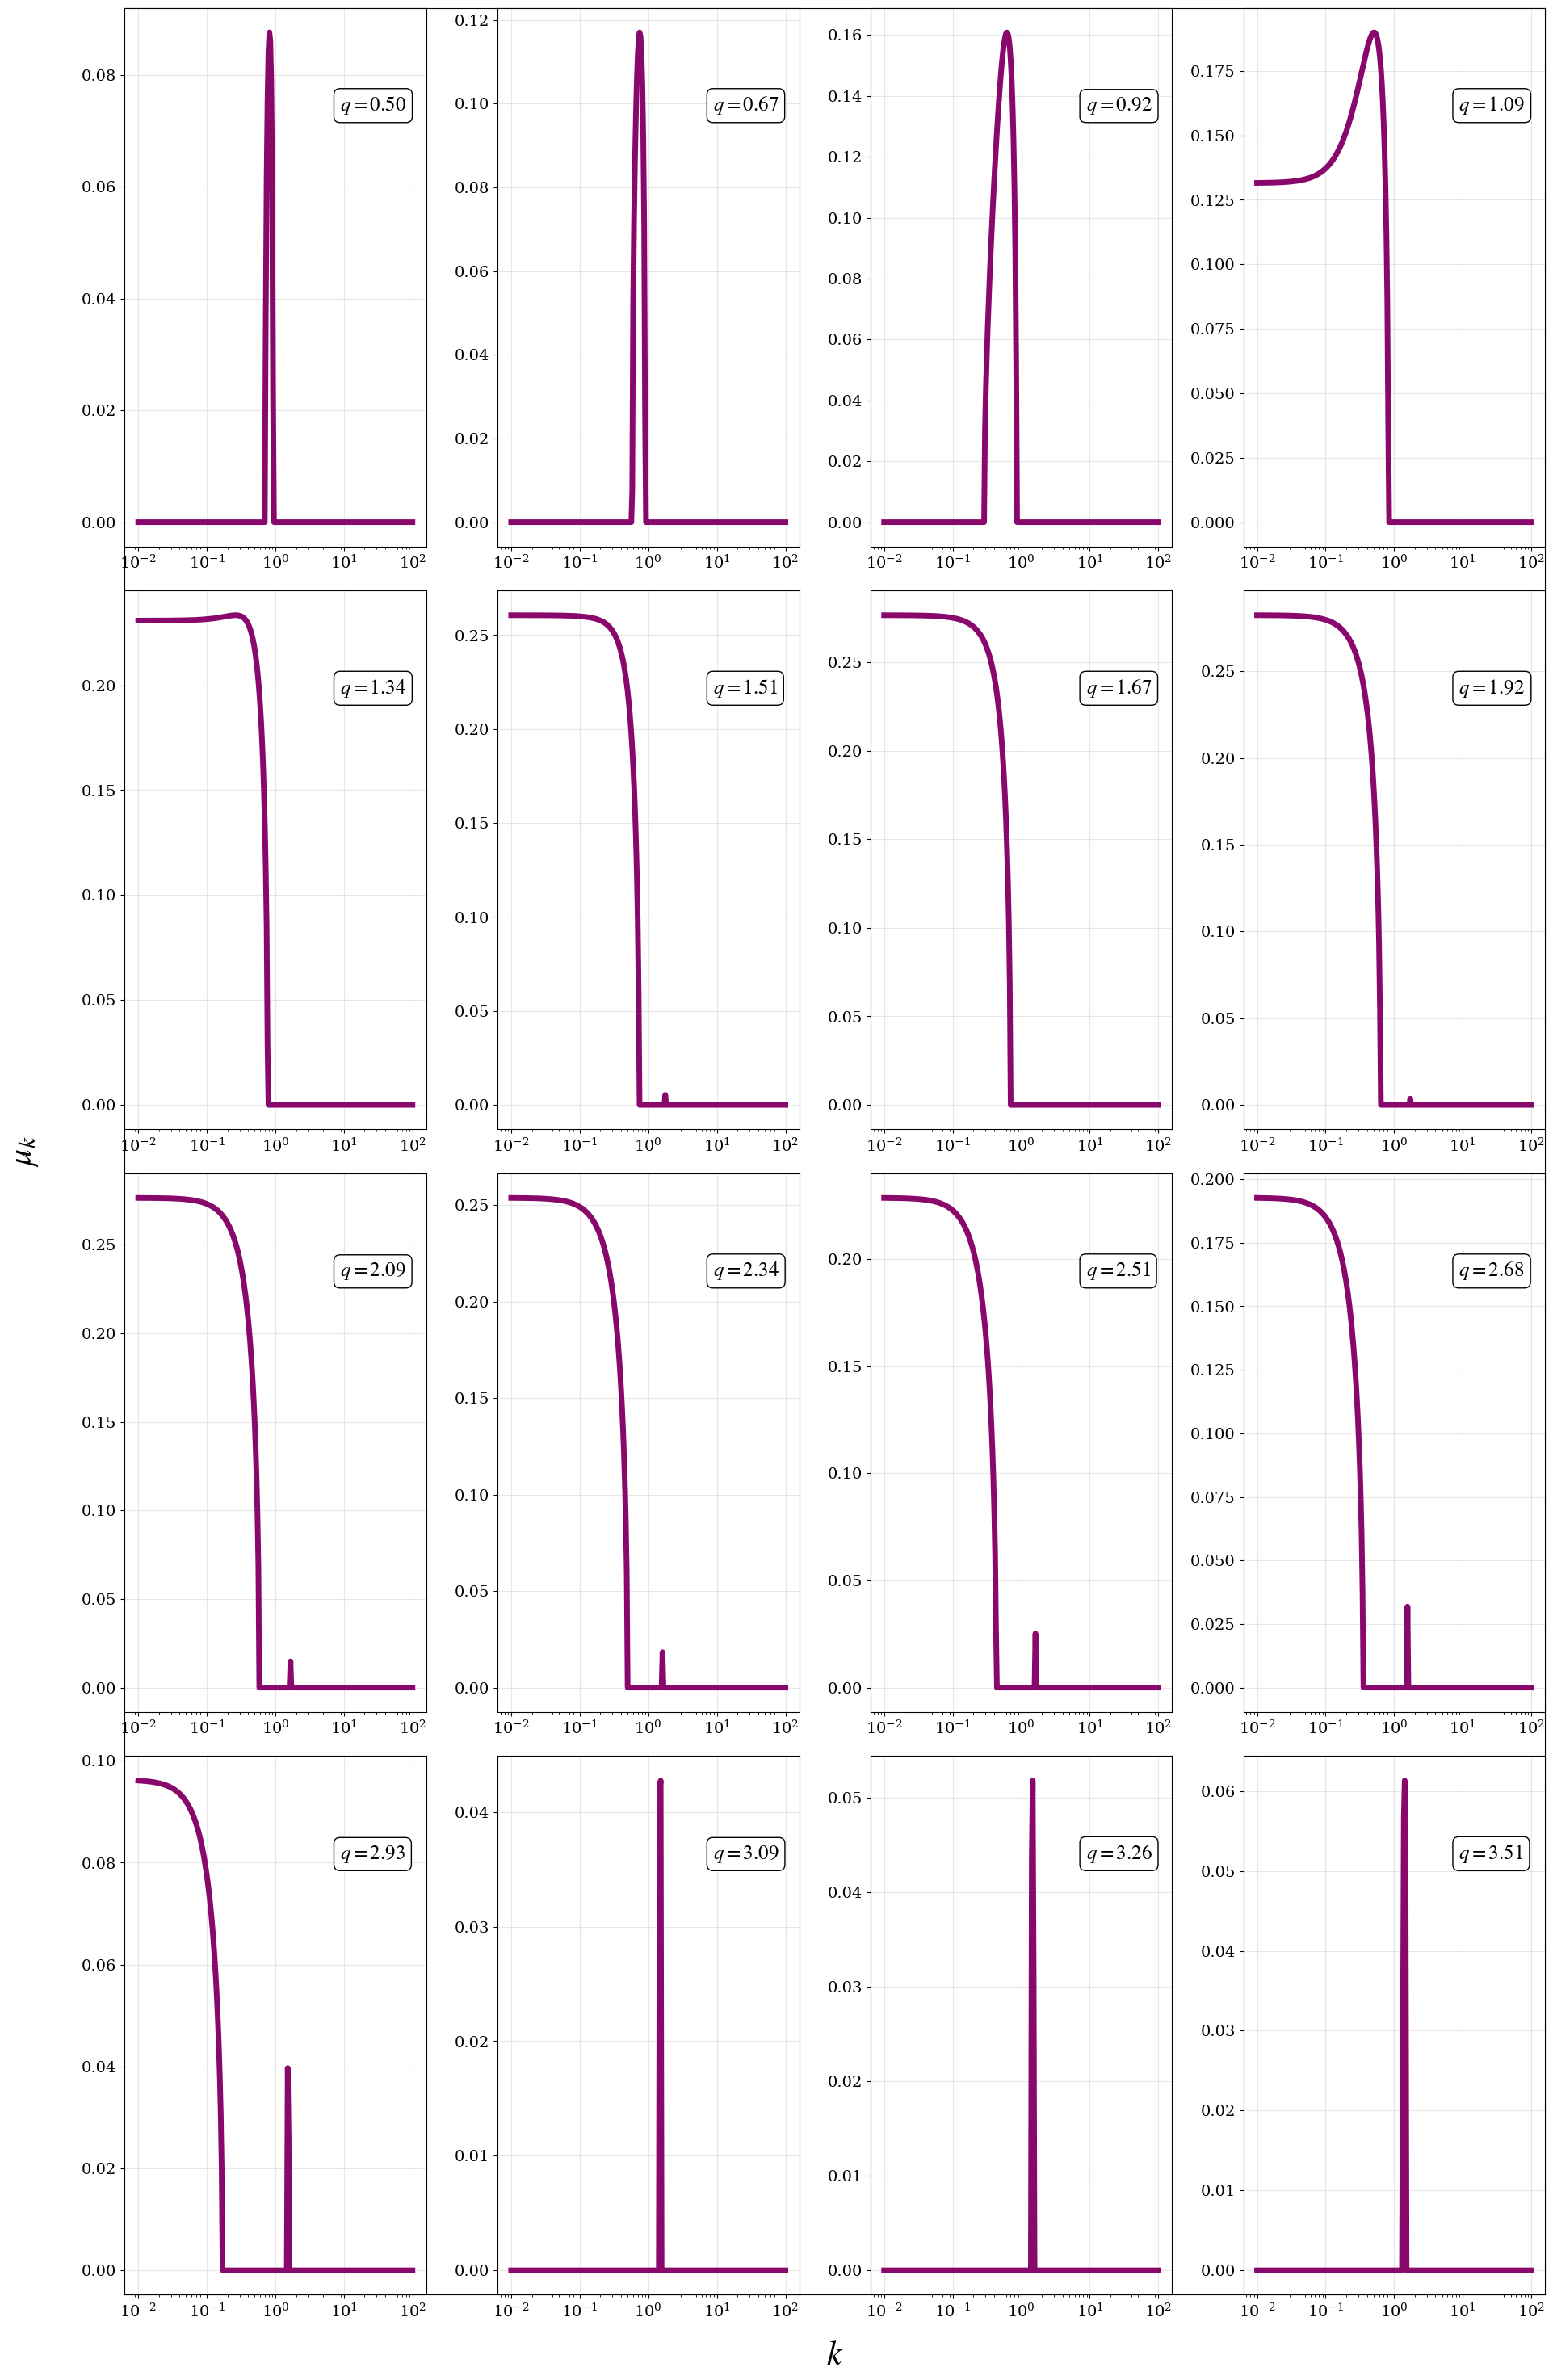

In [9]:
# Diagrama del coeficientente de Floquet en base a k para un g fijo
filename = "Floquet.csv"

data = np.loadtxt(filename, delimiter=",")
qs = data[0, 1:]
ks = data[1:, 0]
mu = data[1:, 1:]

Q = np.linspace(0.5, 3.5, 16)
i = 0

plt.figure(figsize=(20, 30))
plt.xlabel(r'$k$', fontsize=30, labelpad=40)
plt.ylabel(r'$\mu_k$', fontsize=30, labelpad=75)
plt.xticks([])
plt.yticks([])

for q in Q:
    i += 1
    index = (np.abs(qs - q)).argmin()

    plt.subplot(4, 4, i)
    plt.plot(ks, np.real(mu[:, index]), label=f'$q={q}$', lw = 5, color = "#88086c")
    ymin, ymax = plt.gca().get_ylim()
    plt.text(x=ks[-80], y=ymax*0.8, s=rf'$q = {qs[index]:.2f}$', fontsize=18, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
    plt.xscale('log')
    plt.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

### Análisis q = 5050

In [10]:
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)

y0 = (phi0, phi_dot0)
E = 0.5 * phi_dot0**2 + 0.25 * phi0**4

q = 5050
ks = np.logspace(-2, 2, 1000)

# Q, K = np.meshgrid(qs, ks)
mu = np.zeros(len(ks), dtype=complex)
Tosc = oscilation(E)

for j, k in enumerate(tqdm(ks)):
    mu[j] = mu_lphi4(k, q, y0, Tosc)

100%|██████████| 1000/1000 [05:18<00:00,  3.14it/s]


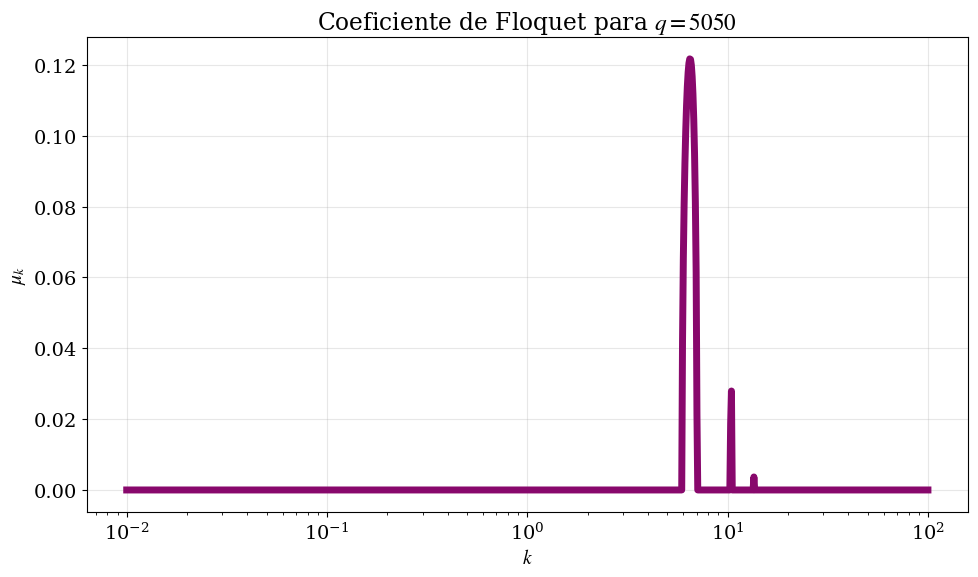

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(ks, np.real(mu), label=f'$q={q}$', lw = 5, color = "#88086c")
plt.xlabel(r'$k$')
plt.ylabel(r'$\mu_k$')
plt.xscale('log')
plt.grid(alpha = 0.3)
plt.title(r'Coeficiente de Floquet para $q=5050$')
plt.tight_layout()
plt.show()

In [12]:
#Calculamos el máximo y el ancho de la banda de inestabilidad
max_mu = np.max(np.real(mu))
k_max = ks[np.argmax(np.real(mu))]
k_delta = ks[np.where(np.real(mu) >= max_mu/2)[0]]

print("k en el máximo de inestabilidad:", k_max)
print("Ancho de la banda de inestabilidad:", k_delta[-1] - k_delta[0])

k en el máximo de inestabilidad: 6.4686076615463275
Ancho de la banda de inestabilidad: 0.9550688389085353


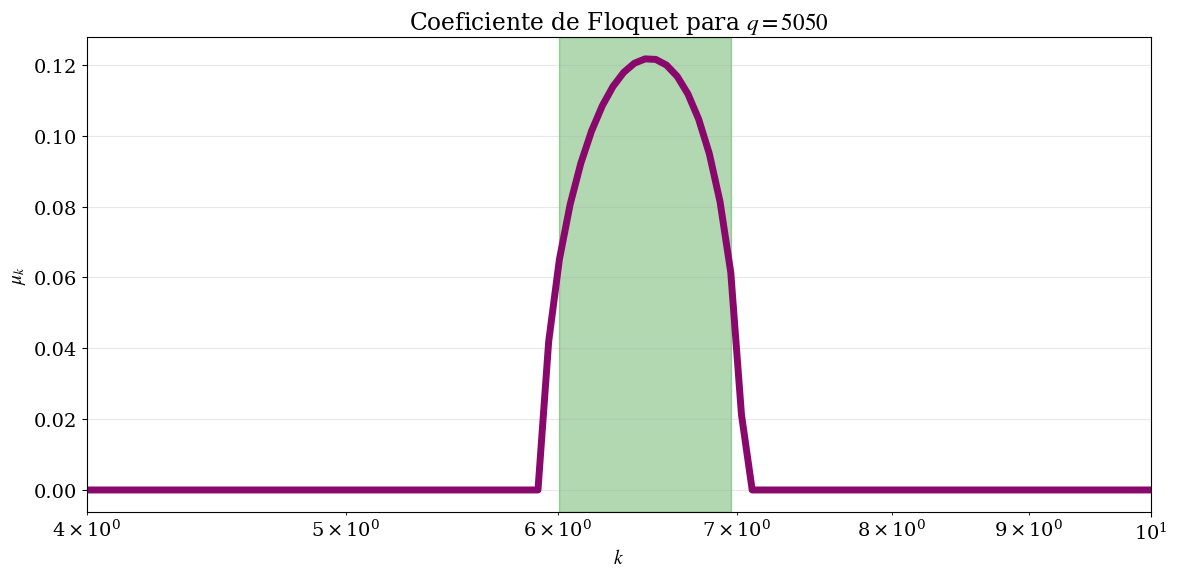

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(ks, np.real(mu), label=f'$q={q}$', lw = 5, color = "#88086c")
plt.xlabel(r'$k$')
plt.ylabel(r'$\mu_k$')
plt.xscale('log')
plt.grid(alpha = 0.3)
plt.title(r'Coeficiente de Floquet para $q=5050$')
plt.axvspan(k_delta[-1], k_delta[0], color='green', alpha=0.3)
plt.xlim(4, 10)
plt.tight_layout()
plt.show()

## Broad vs. Narrow resonance

In [14]:
"""Parámetros"""

# Narrow Resonance
qn = 0.5
kn = 0.8277856966198477

# Broad Resonance
qb = 5050
kb = 6.4686076615463275

# Condiciones iniciales
y0 = CI(kn, qn)
phi0, phi_dot0 = y0[0], y0[1]

# Tiempos
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)

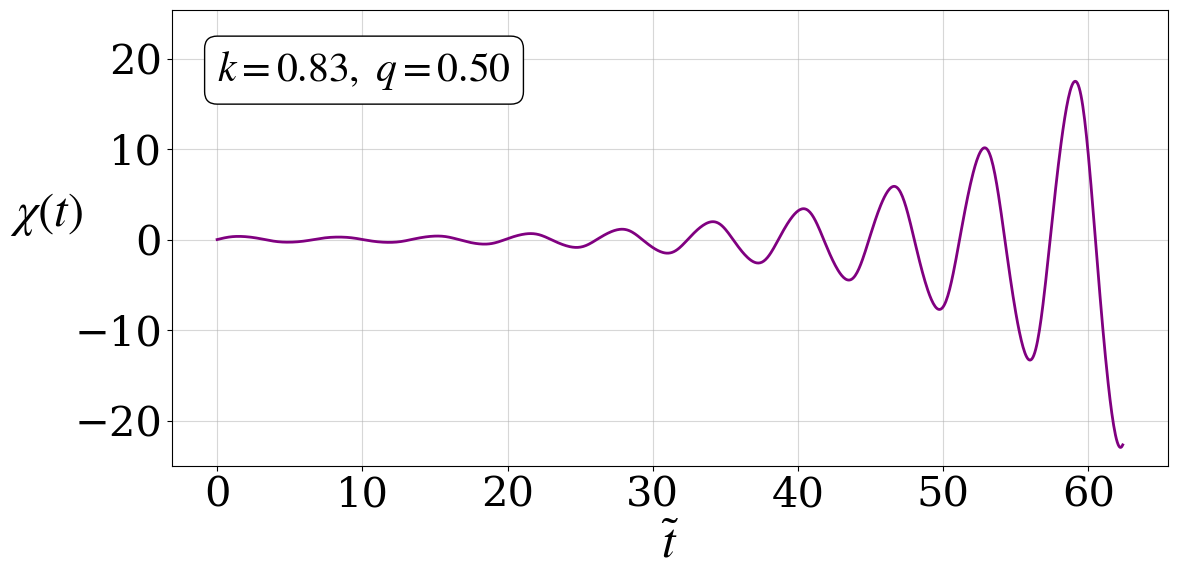

In [15]:
sol_narrow = solve_ivp(pert, t_span, y0, t_eval=np.linspace(t_span[0], t_span[-1], 1000), method='RK45', rtol=1e-6, args=(kn, qn))

plt.figure(figsize=(12, 6))
plt.plot(sol_narrow.t, sol_narrow.y[2], lw = 2, color = "purple")
ymin, ymax = plt.gca().get_ylim()
plt.ylim(ymin, ymax*1.3)
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$\chi(t)$', labelpad=20, rotation='horizontal', fontsize = 35)
plt.text(x=sol_narrow.t[0], y=ymax*0.9, s=rf'$k = {kn:.2f}, ~ q = {qn:.2f}$', fontsize=30, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
plt.grid(alpha=0.5)
#plt.show()
plt.savefig("Narrow_Resonance_lphi4.pdf", format = "pdf")

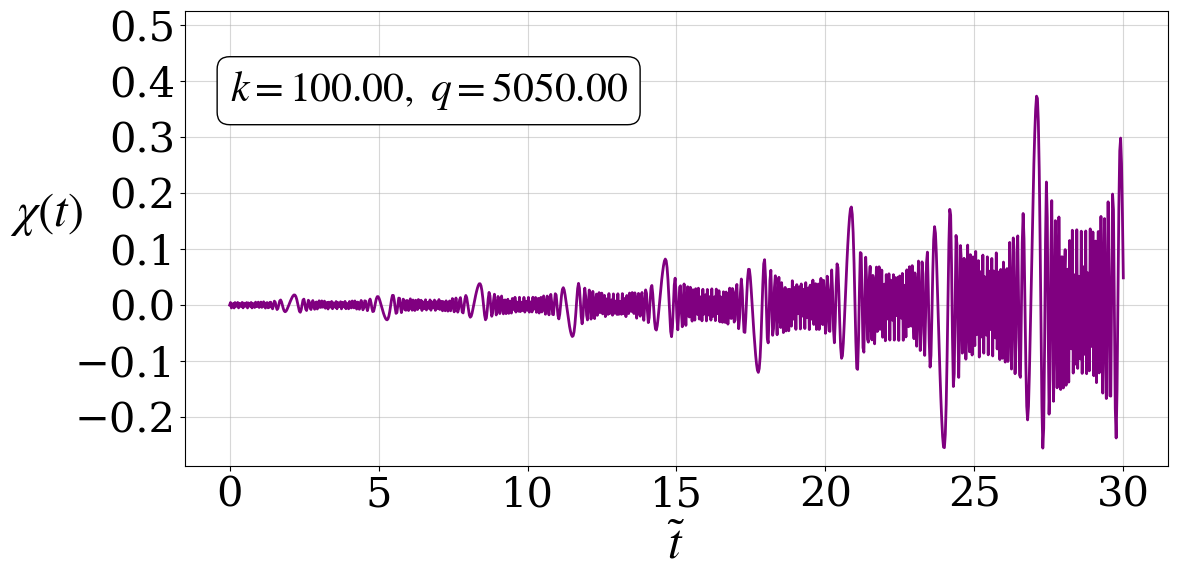

In [16]:
sol_broad = solve_ivp(pert, t_span, y0, t_eval=np.linspace(t_span[0], 30, 1000), method='RK45', rtol=1e-6, args=(kb, qb))

plt.figure(figsize=(12, 6))
plt.plot(sol_broad.t, sol_broad.y[2], lw = 2, color = "purple")
plt.grid(alpha=0.5)
ymin, ymax = plt.gca().get_ylim()
plt.ylim(ymin, ymax*1.3)
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$\chi(t)$', labelpad=20, rotation='horizontal', fontsize = 35)
plt.text(x=sol_broad.t[0], y=ymax*0.9, s=rf'$k = {k:.2f}, ~ q = {q:.2f}$', fontsize=30, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
#plt.show()
plt.savefig("Broad_Resonance_lphi4.pdf", format = "pdf")

## Número de partículas

El número de partículas del campo hijo estará dado por

$$n_\chi (k) = \frac{1}{2 \Omega_\chi} \left( \left| \frac{d \chi_k}{dT} \right|^2 + \Omega^2_\chi \left| \chi_k \right|^2 \right) - \frac{1}{2}$$

dónde

$$\Omega_\chi^2 (k, t) = \frac{k^2}{a^2} + g^2 \phi^2 (t)$$

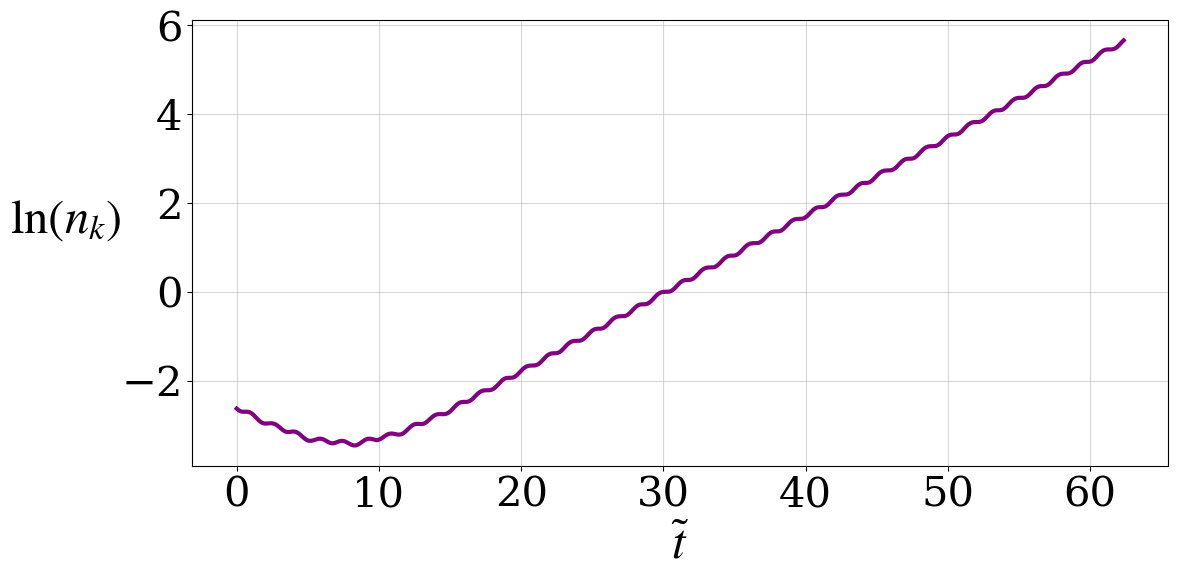

In [17]:
nk = number(kn, qn, sol_narrow.y[0], sol_narrow.y[2], sol_narrow.y[3], 1)
t = sol_narrow.t

plt.figure(figsize=(12, 6))
plt.plot(t, np.log(nk), lw = 3, color = "purple")
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$\ln(n_k)$', fontsize = 35, rotation='horizontal', labelpad=40)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha=0.5)
plt.tight_layout()
#plt.show()
plt.savefig("nk_Narrow_Resonance_lphi4.pdf", format = "pdf")

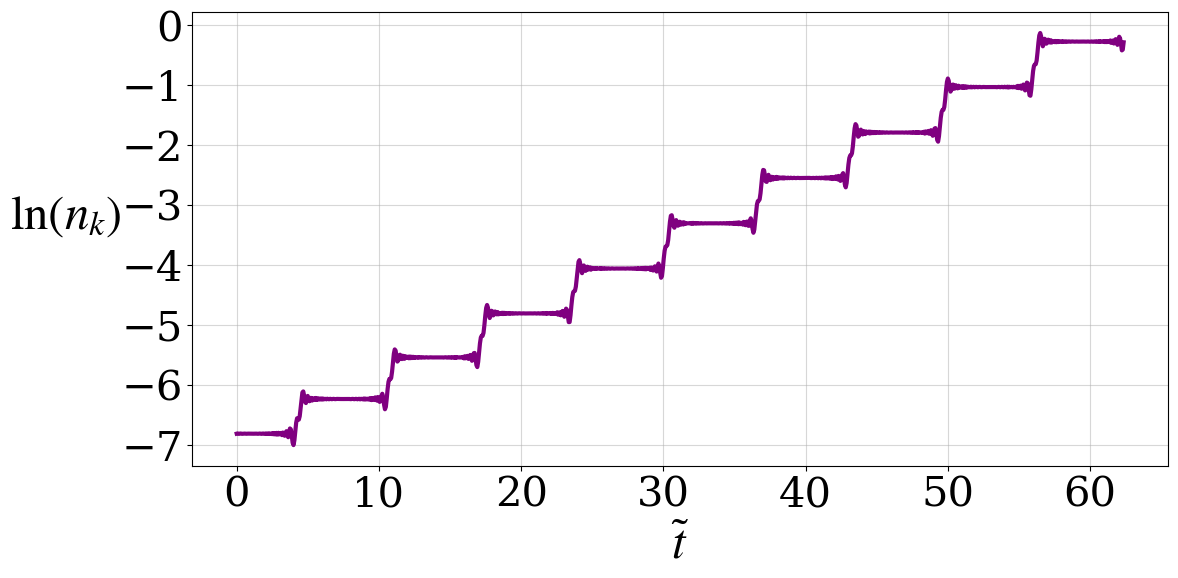

In [18]:
nk = number(kb, qb, sol_broad.y[0], sol_broad.y[2], sol_broad.y[3], 1)
t = sol_narrow.t

plt.figure(figsize=(12, 6))
plt.plot(t, np.log(nk), lw = 3, color = "purple")
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$\ln(n_k)$', fontsize = 35, rotation='horizontal', labelpad=40)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha=0.5)
plt.tight_layout()
#plt.show()
plt.savefig("nk_Broad_Resonance_lphi4.pdf", format = "pdf")

# Dinámica con expansión

In [19]:
# Narrow Resonance
qn = 0.5
kn = 0.8277856966198477

# Broad Resonance
qb = 5050
kb = 6.4686076615463275

# Condiciones iniciales
y0_exp = CI_exp(kn, qn)
phi0, phi_dot0 = y0_exp[0], y0_exp[1]

# Tiempos
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)

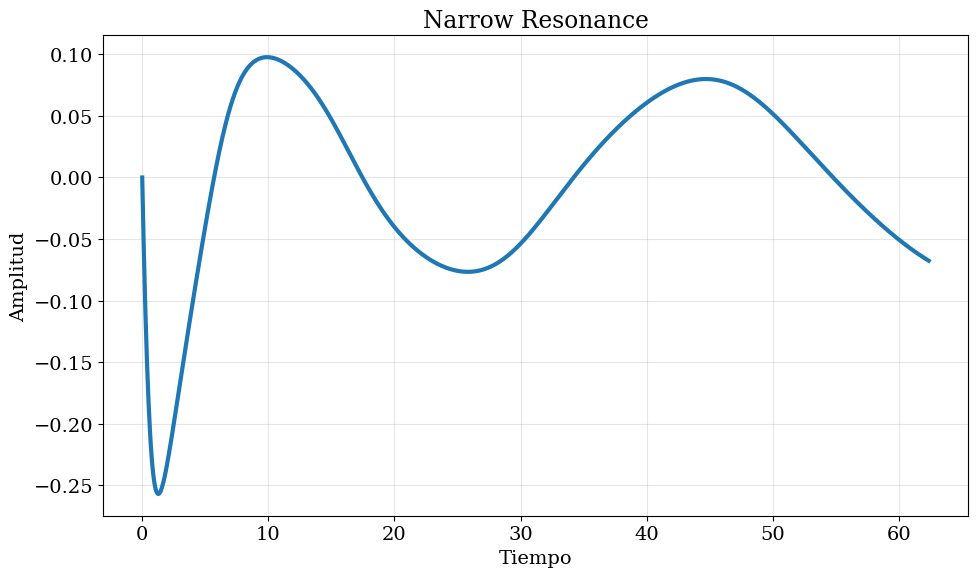

In [20]:
sol_narrow = solve_ivp(pert_exp, t_span, y0_exp, t_eval=np.linspace(t_span[0], t_span[-1], 1000), method='RK45', rtol=1e-6, args=(kn, qn))

plt.figure(figsize=(10, 6))
plt.plot(sol_narrow.t, sol_narrow.y[2], label=r'$\chi_k(t)$', lw = 3)
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.title(r'Narrow Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

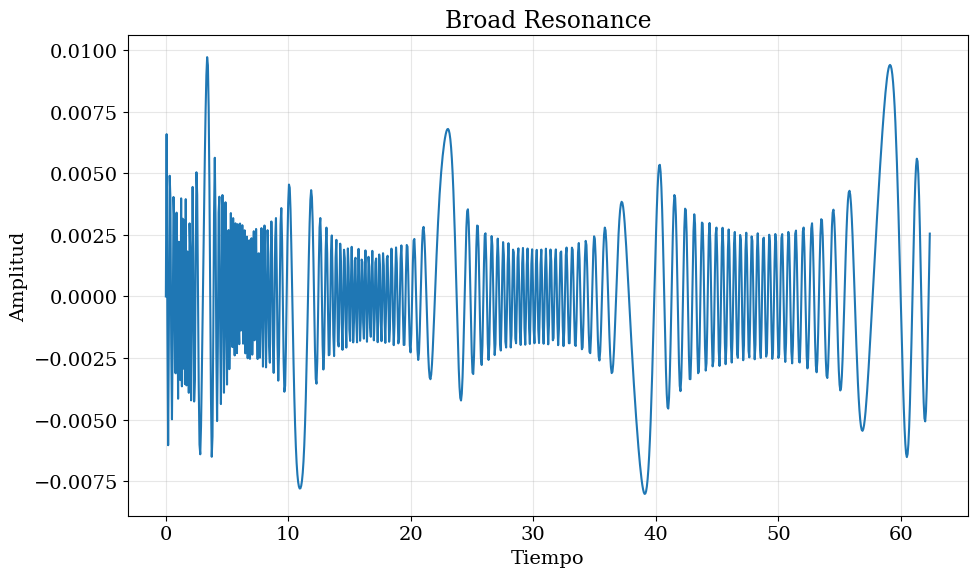

In [21]:
sol_broad = solve_ivp(pert_exp, t_span, y0_exp, t_eval=np.linspace(t_span[0], t_span[-1], 1000), method='RK45', rtol=1e-6, args=(kb, qb))

plt.figure(figsize=(10, 6))
plt.plot(sol_broad.t, sol_broad.y[2], label=r'$\chi_k(t)$')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.title(r'Broad Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Evolución del background

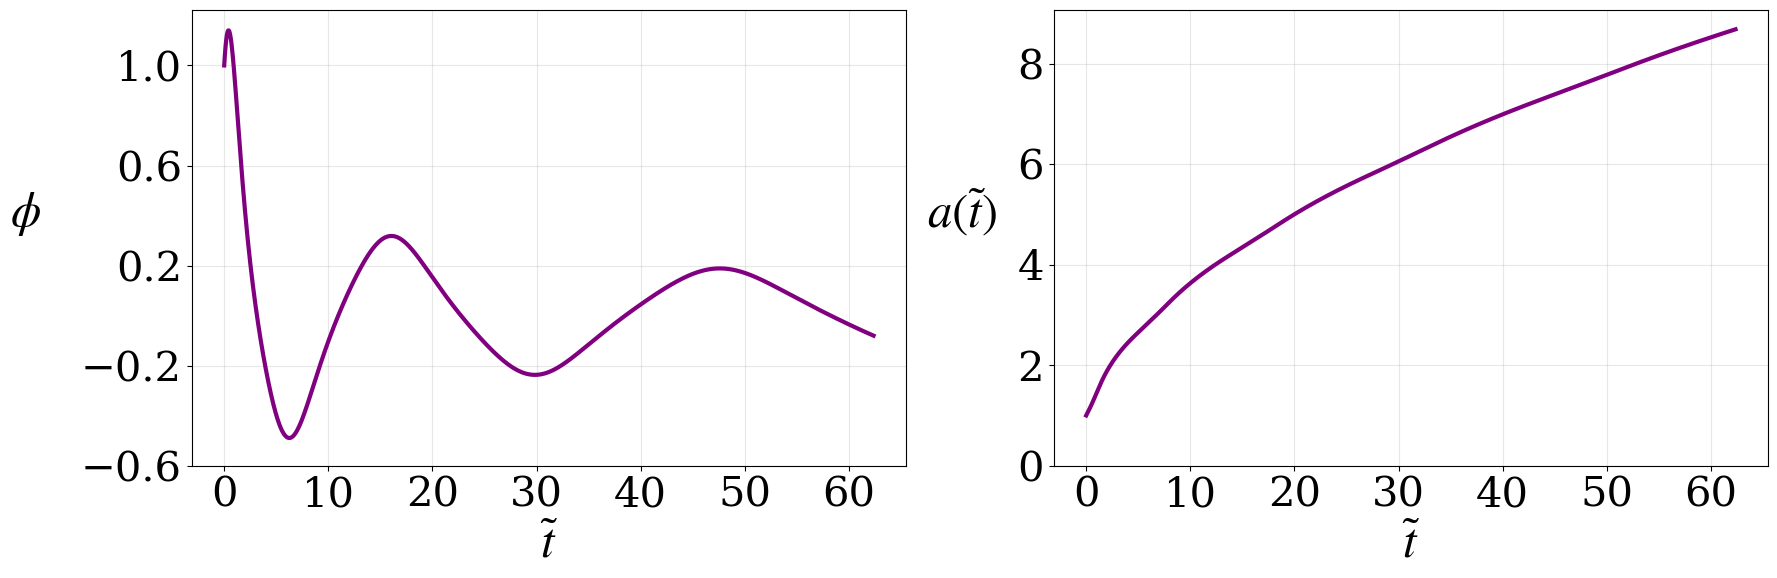

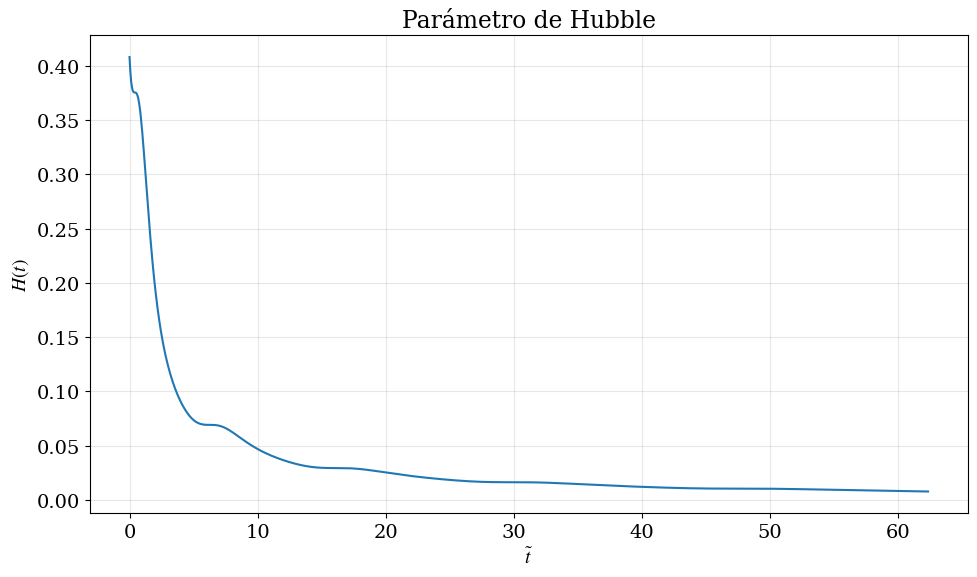

In [22]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.plot(sol_broad.t, sol_broad.y[0],lw = 3, color = "purple")
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$\phi$', fontsize = 35, rotation='horizontal', labelpad=40)
plt.xticks(fontsize=30)
plt.yticks(np.arange(-0.6, 1.2, 0.4), fontsize=30)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(sol_broad.t, sol_broad.y[4],lw = 3, color = "purple")
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$a(\tilde{t})$', fontsize = 35, rotation='horizontal', labelpad=40)
plt.xticks(fontsize=30)
plt.yticks(np.arange(0, 9.2, 2), fontsize=30)
plt.grid(alpha=0.3)

plt.tight_layout()
#plt.show()
plt.savefig("Background_lphi4.pdf", format = "pdf")

plt.figure(figsize=(10, 6))
plt.plot(sol_broad.t, sol_broad.y[5]/sol_broad.y[4], label=r'$\chi_k(t)$')
plt.xlabel(r'$\tilde{t}$')
plt.ylabel(r'$H(t)$')
plt.title(r'Parámetro de Hubble')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Número de partículas

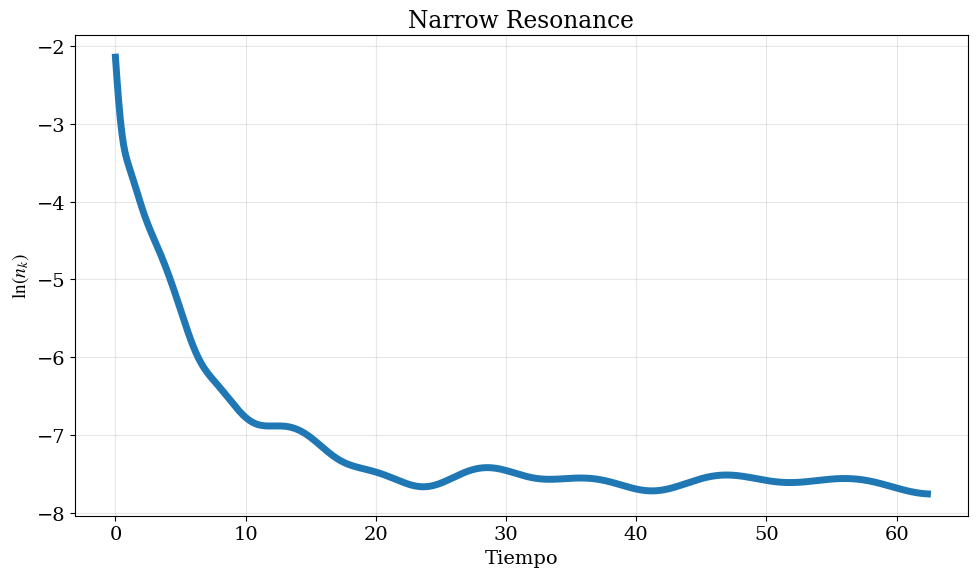

In [23]:
nk = number(kn, qn, sol_narrow.y[0], sol_narrow.y[2], sol_narrow.y[3], sol_broad.y[4])
t = sol_narrow.t

plt.figure(figsize=(10, 6))
plt.plot(t, np.log(nk), lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\ln(n_k)$')
plt.title(r'Narrow Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

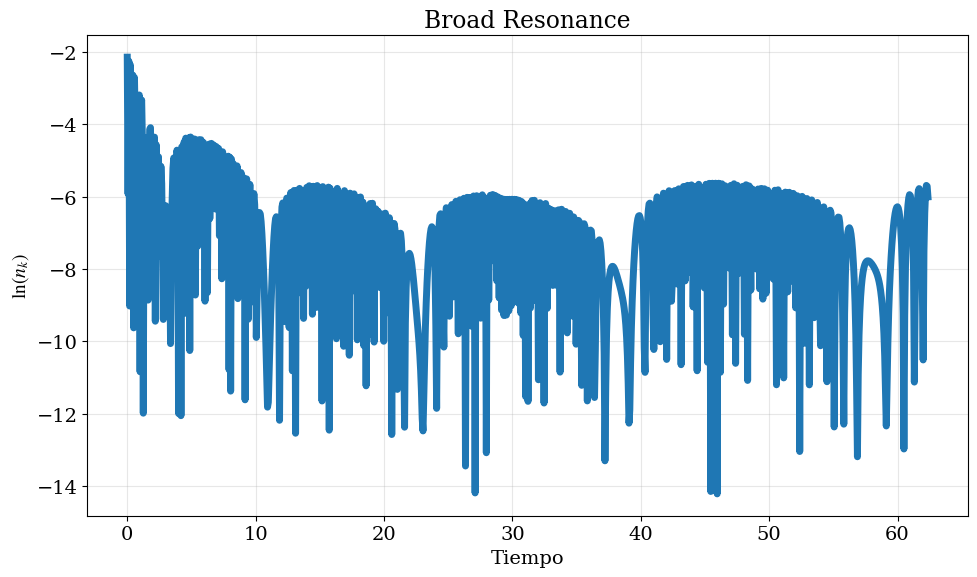

In [24]:
nk = number(kn, qn, sol_broad.y[0], sol_broad.y[2], sol_broad.y[3], sol_broad.y[4])
t = sol_narrow.t

plt.figure(figsize=(10, 6))
plt.plot(t, np.log(nk), lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\ln(n_k)$')
plt.title(r'Broad Resonance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Espectro de potencias

## Sin expansión

In [25]:
"""Parámetros"""
q = 5050
n_k = 2000
ks = np.logspace(-2, 2, n_k)
chi_vals = np.zeros(n_k)

# Tiempos
phi0 = 1; phi_dot0 = phi0**2/np.sqrt(2)
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)

In [26]:
# Calculo el espectro de potencias para el tiempo final
t_chi, chi_k = chi_modes(q, ks, t_span, n_t=500)
P_chi_vals = (ks**3 / (2 * np.pi**2)) * np.abs(chi_k[:, -1])**2

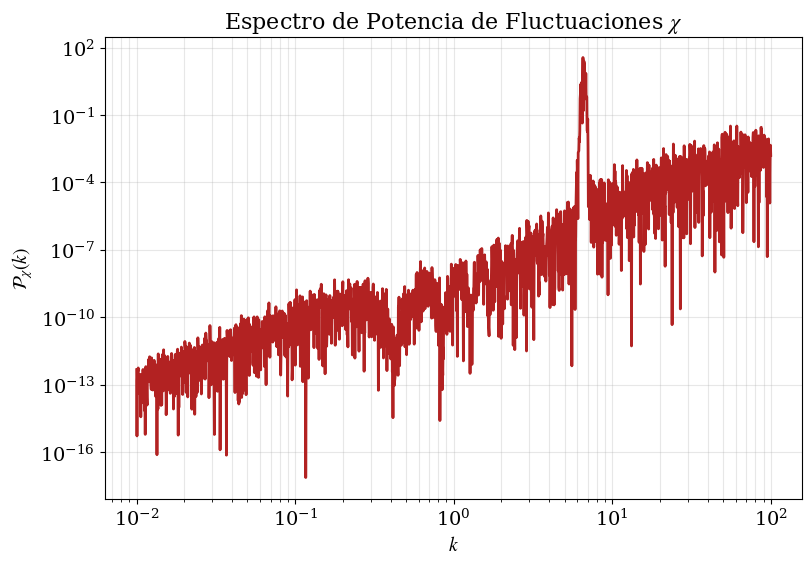

In [27]:
plt.figure(figsize=(9, 6))
plt.plot(ks, P_chi_vals, lw=2, color='firebrick')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\mathcal{P}_{\chi}(k)$', fontsize=14)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

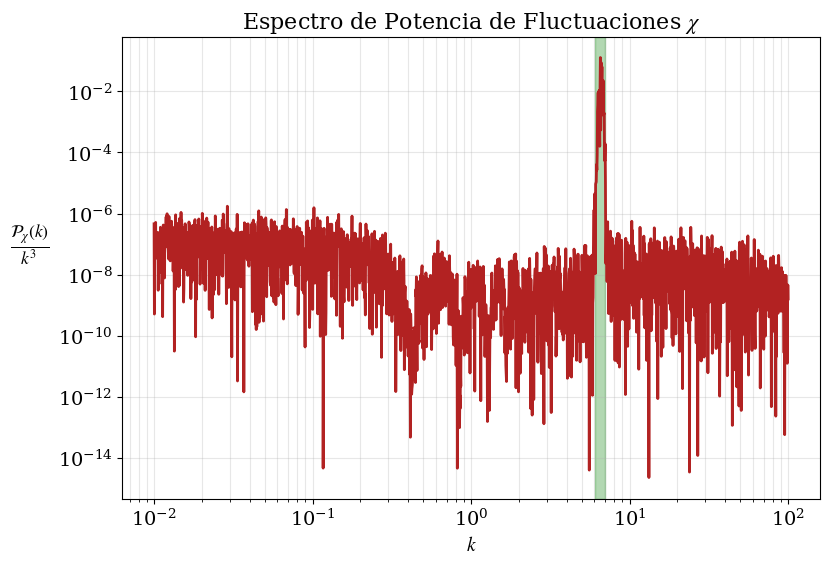

In [28]:
plt.figure(figsize=(9, 6))
plt.plot(ks, P_chi_vals/ks**3, lw=2, color='firebrick')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\frac{\mathcal{P}_{\chi}(k)}{k^3}$', fontsize=18, rotation='horizontal', labelpad=20)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.axvspan(k_delta[-1], k_delta[0], color='green', alpha=0.3)
plt.grid(True, which="both", alpha=0.3)
plt.show()

### Espectro para varios tiempos

In [29]:
"""Parámetros"""
q = 5050
n_k = 1000
ks = np.logspace(-2, 2, n_k)
chi_values = np.zeros(n_k)

# Tiempos
phi0 = 1; phi_dot0 = phi0**2/np.sqrt(2)
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
tiempos = [3*Tosc, 5*Tosc, 8*Tosc, 10*Tosc]

In [30]:
"""Calculo del espectro de potencias P_chi(k)"""
Pt = np.zeros((len(tiempos), n_k))
t_chi, chi_k = chi_modes(q, ks, t_span, n_t=500)

# Para cada tiempo final, selecciono el índice más cercano en la malla t_chi
for i, t_final in enumerate(tiempos):
    idx = np.argmin(np.abs(t_chi - t_final))
    chi_t = chi_k[:, idx]
    P_chi_vals = (ks**3 / (2 * np.pi**2)) * np.abs(chi_t)**2
    Pt[i, :] = P_chi_vals

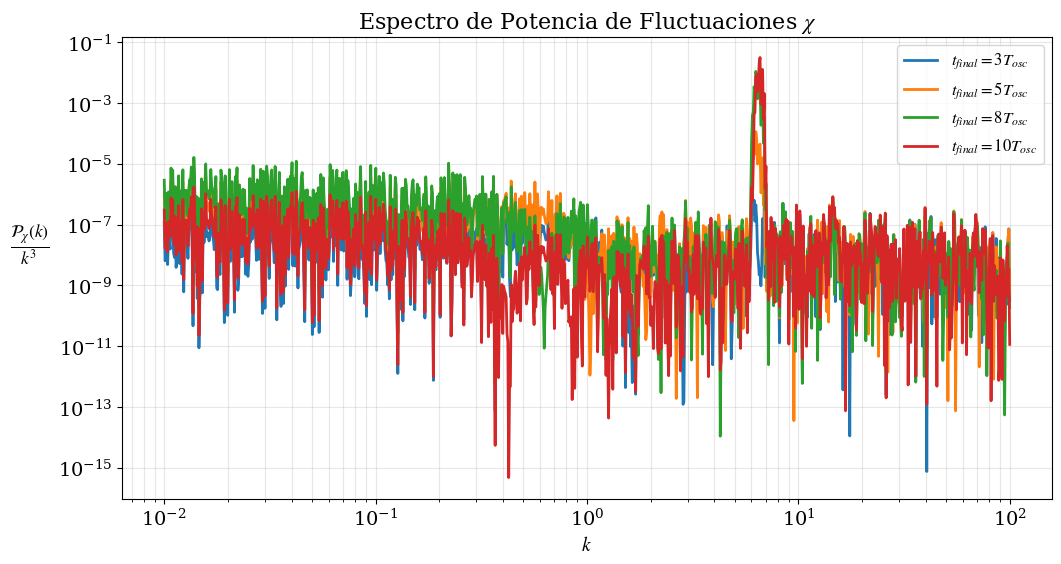

In [31]:
"""Graficar los resultados"""
plt.figure(figsize=(12, 6))
for i, t_final in enumerate(tiempos):
    plt.plot(ks, Pt[i,:]/ks**3, lw=2, label=rf'$t_{{final}} = {t_final/Tosc:.0f} T_{{osc}}$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\frac{\mathcal{P}_{\chi}(k)}{k^3}$', fontsize=18, rotation='horizontal', labelpad=20)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=12)
plt.show()

## Con expansión

In [32]:
"""Parámetros"""
q = 5050
n_k = 1000
ks = np.logspace(-2, 2, n_k)
chi_values = np.zeros(n_k)

# Tiempos
phi0 = 1; phi_dot0 = phi0**2/np.sqrt(2)
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)

In [33]:
# Calculo el espectro de potencias para el tiempo final
t_chi, chi_k, at = chi_modes_exp(q, ks, t_span, n_t=500)
P_chi_vals = (ks**3 / (2 * np.pi**2)) * np.abs(chi_k[:, -1])**2

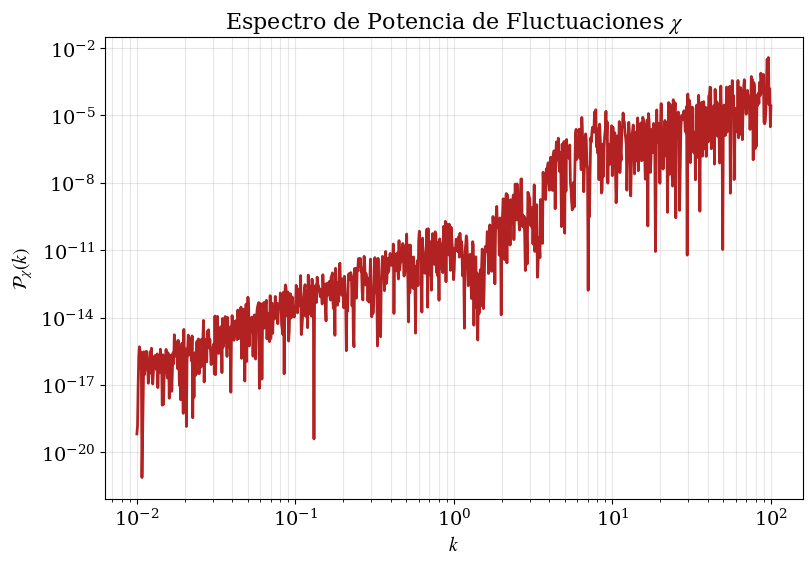

In [34]:
plt.figure(figsize=(9, 6))
plt.plot(ks, P_chi_vals, lw=2, color='firebrick')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\mathcal{P}_{\chi}(k)$', fontsize=14)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

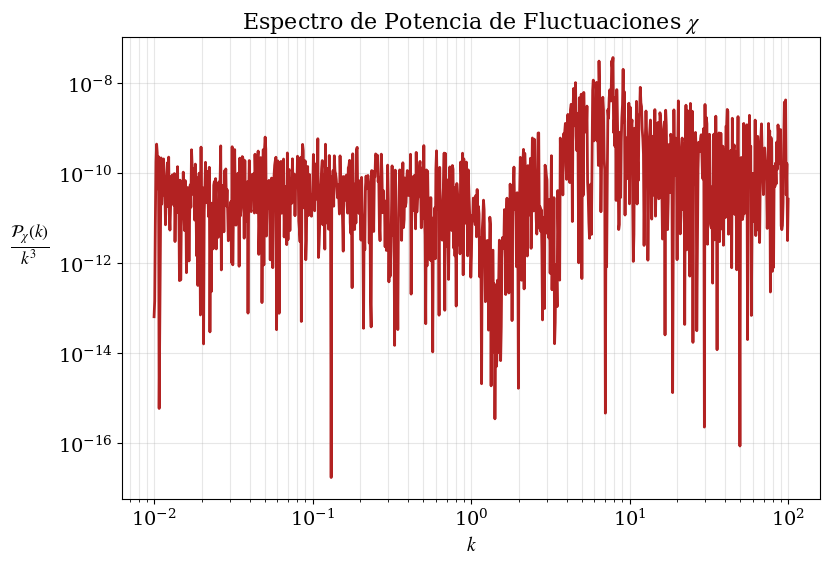

In [35]:
plt.figure(figsize=(9, 6))
plt.plot(ks, P_chi_vals/ks**3, lw=2, color='firebrick')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\frac{\mathcal{P}_{\chi}(k)}{k^3}$', fontsize=18, rotation='horizontal', labelpad=20)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

### Espectro para varios tiempos

In [36]:
"""Parámetros"""
q = 5050
n_k = 1000
ks = np.logspace(-2, 2, n_k)
chi_values = np.zeros(n_k)

# Tiempos
phi0 = 1; phi_dot0 = phi0**2/np.sqrt(2)
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
tiempos = [3*Tosc, 5*Tosc, 8*Tosc, 10*Tosc]

In [37]:
"""Calculo del espectro de potencias P_chi(k)"""
Pt = np.zeros((len(tiempos), n_k))
t_chi, chi_k, at = chi_modes_exp(q, ks, t_span, n_t=500)

# Para cada tiempo final, selecciono el índice más cercano en la malla t_chi
for i, t_final in enumerate(tiempos):
    idx = np.argmin(np.abs(t_chi - t_final))
    chi_t = chi_k[:, idx]
    P_chi_vals = (ks**3 / (2 * np.pi**2)) * np.abs(chi_t)**2
    Pt[i, :] = P_chi_vals

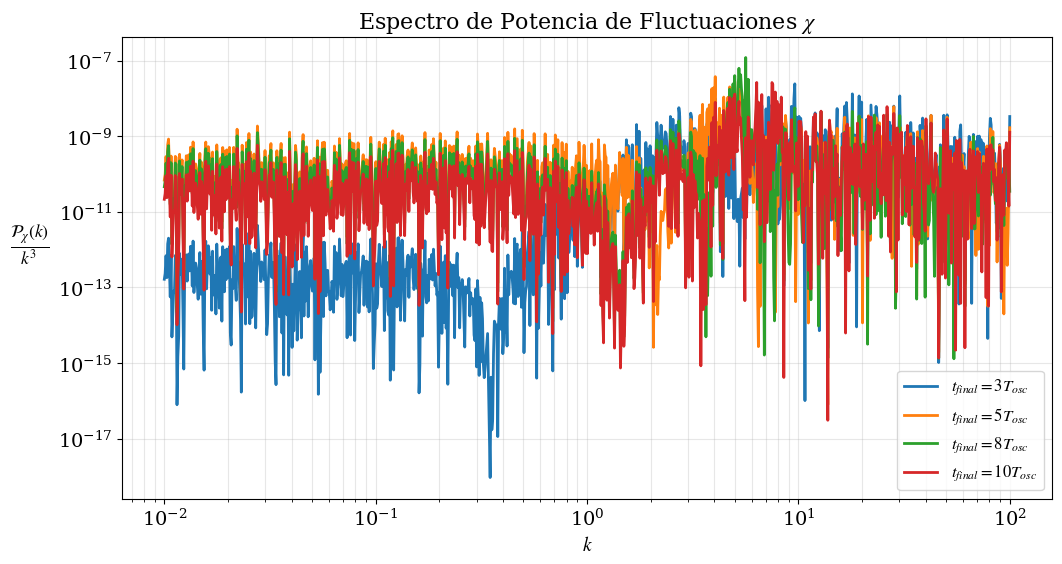

In [38]:
"""Graficar los resultados"""
plt.figure(figsize=(12, 6))
for i, t_final in enumerate(tiempos):
    plt.plot(ks, Pt[i,:]/ks**3, lw=2, label=rf'$t_{{final}} = {t_final/Tosc:.0f} T_{{osc}}$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\frac{\mathcal{P}_{\chi}(k)}{k^3}$', fontsize=18, rotation='horizontal', labelpad=20)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=12)
plt.show()

# GW Production

Para poder calcular la densidad de energía de ondas gravitacionales debemos utilizar

$$\frac{d \rho_{GW}}{d \log k} = \frac{k^3}{16 \pi^4 m_p^2 a^4} \int p^6 \sin^5 \theta ~ \left[ \left| I_{(c)} (k, p, \theta, \tau)  \right|^2 + \left| I_{(s)} (k, p, \theta, \tau)  \right|^2 \right] ~ dp ~ d\theta$$

dónde $I_{(s)}$ e $I_{(c)}$ están definidas a partir de

$$I_{(c)} (k, p, \theta, \tau) = \int_{\tau_{i}}^\tau  \frac{\cos (k\tau^\prime)}{a \left( \tau^\prime \right)} ~ \chi^{(c)}_{p} (\tau^\prime) ~ \chi_{k - p}^{(c)} (\tau^\prime) ~ d\tau^\prime$$

$$I_{(s)} (k, p, \theta, \tau) = \int_{\tau_{i}}^\tau  \frac{\sin (k\tau^\prime)}{a \left( \tau^\prime \right)} ~ \chi^{(c)}_{p} (\tau^\prime) ~ \chi_{k - p}^{(c)} (\tau^\prime) ~ d\tau^\prime$$

y los $\chi_k^{(c)}$ es la dinámica del campo hijo que conseguimos previamente

Podemos plantear $x = \cos \theta$ de modo tal que la integral a resolver se escribe como

$$\frac{d \rho_{GW}}{d \log k} = \frac{k^3}{16 \pi^4 m_p^2 a^4} \int_{p_0}^{p_f} \int_{-1}^{1} p^6 \left( 1 - x^2 \right)^2 \left[ \left| I_c \left( k, p, x, t \right) \right|^2 + \left| I_s \left( k, p, x, t \right) \right|^2 \right] ~ dp ~ dx$$

In [39]:
# Parámetros fijos
q = 5050
p0, pf = 0.1, 10  
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2 / np.sqrt(2)
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
ti, tf = 0, 10*Tosc

# Rango de k
ks = np.logspace(0, 1, 10000)  
rhoGW_values = []

# crear interpolador temporal de modos (permitir extrapolación)
t_chi, chi_k = chi_modes(q, ks, (ti, tf), n_t=500)
chi_interp = interp1d(ks, chi_k, axis=0, bounds_error=False, fill_value='extrapolate')

# prueba rápida con mallas pequeñas
rhoGW_values = []
for k in tqdm(ks, desc="Calculando rhoGW"):
    rho = rhoGW(k=k, t_chi=t_chi, chi_interp=chi_interp, p0=p0, pf=pf, n_p=40, n_x=40)
    rhoGW_values.append(k**3 * rho/(16 * np.pi**4))
rhoGW_values = np.array(rhoGW_values)

Calculando rhoGW:   0%|          | 0/10000 [00:00<?, ?it/s]/tmp/ipykernel_19423/537220381.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  int_over_x = np.trapz(integrand_px, x_grid, axis=1)
/tmp/ipykernel_19423/537220381.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho_val = np.trapz(int_over_x, p_grid)
Calculando rhoGW: 100%|██████████| 10000/10000 [05:14<00:00, 31.82it/s]


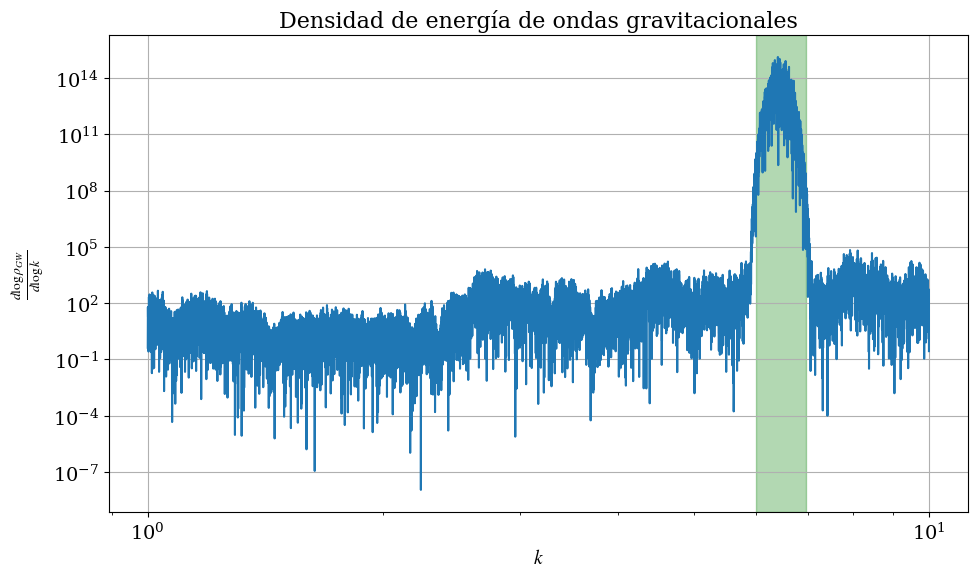

In [40]:
# Graficar
plt.figure(figsize=(10, 6))
plt.plot(ks, rhoGW_values, label=r'$\rho_{GW}(k)$')
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\frac{d \log \rho_{GW}}{d \log k}$', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.title(r'Densidad de energía de ondas gravitacionales', fontsize=16)
plt.grid(True)
plt.axvspan(k_delta[-1], k_delta[0], color='green', alpha=0.3)
plt.tight_layout()
#plt.show()
plt.savefig("rhoGW_lphi4(lineal).pdf", format = "pdf")

In [41]:
# Resolver el sistema de fondo para obtener a(t) y a_dot(t)
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2 / np.sqrt(2)
areh = 1.0
a_dotreh = np.sqrt((phi_dot0**2/2 + phi0**4/4) / 3) * areh
t_eval = np.linspace(ti, tf, 500)

def background_exp(t, y):
    phi, phi_dot, a, a_dot = y
    H = a_dot / a
    phi_ddot = -3.0 * H * phi_dot - phi**3
    a_ddot = - a/3.0 * (phi_dot**2 - phi**4 / 4.0)
    return [phi_dot, phi_ddot, a_dot, a_ddot]

sol_bg = solve_ivp(background_exp, (ti, tf), [phi0, phi_dot0, areh, a_dotreh], t_eval=t_eval, method='RK45', rtol=1e-6)
a_t = sol_bg.y[2]
a_dot_t = sol_bg.y[3]

# Interpoladores globales
a_interp = interp1d(sol_bg.t, a_t, kind='cubic', bounds_error=False, fill_value='extrapolate')
a_dot_interp = interp1d(sol_bg.t, a_dot_t, kind='cubic', bounds_error=False, fill_value='extrapolate')

2.3847180625290346e-06


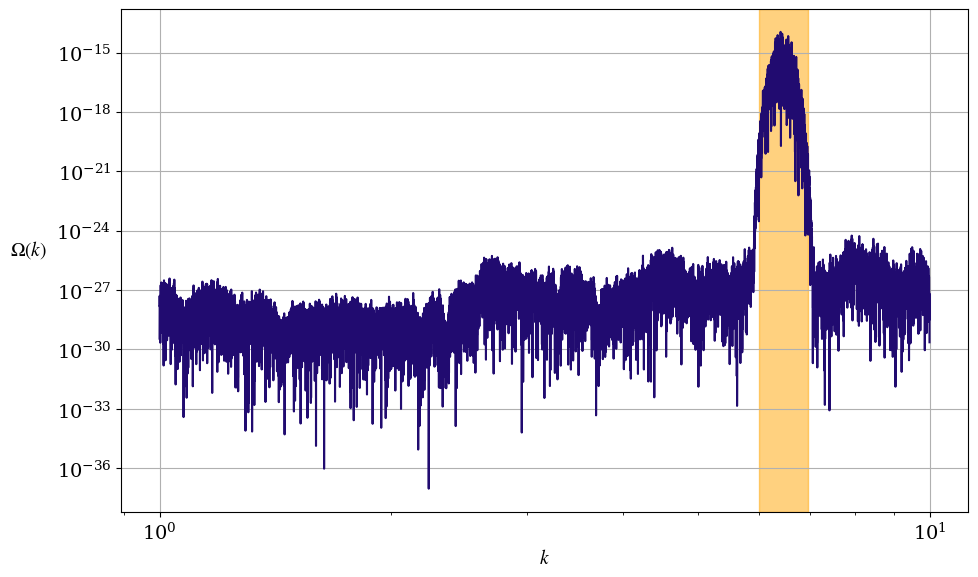

In [43]:
rhoc = 3 * (a_dot_interp(tf)/a_interp(tf))**2 / (8 * np.pi)  # Densidad crítica al tiempo final
mp = 2.435e19 # GeV
print(rhoc)
# Graficar
plt.figure(figsize=(10, 6))
plt.plot(ks, rhoGW_values/(mp**(3/2)), label=r'$\rho_{GW}(k)$', color = "#210b70")
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\Omega (k)$', fontsize=14, rotation='horizontal', labelpad=20)
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.axvspan(k_delta[-1], k_delta[0], color='orange', alpha=0.5)
plt.tight_layout()
#plt.show()
plt.savefig("rhoGW_lphi4(lineal).pdf", format = "pdf")